In [430]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

AttributeError: module 'seaborn' has no attribute 'color_pallet'

In [2]:
df=pd.read_csv("Headway Data, 8-1-2023 to 9-30-2023.csv")

In [5]:
print(df.head())

   CALENDAR_ID  SERVICE_ABBR  ADHERENCE_ID        DATE  ROUTE_ABBR  \
0    120230801             1      99457890  2023-08-01          22   
1    120230801             1      99457891  2023-08-01          22   
2    120230801             1      99457892  2023-08-01          22   
3    120230801             1      99457893  2023-08-01          22   
4    120230801             1      99457894  2023-08-01          22   

   BLOCK_ABBR  OPERATOR  TRIP_ID  OVERLOAD_ID ROUTE_DIRECTION_NAME  ...  \
0        2200      1040   345104            0          TO DOWNTOWN  ...   
1        2200      1040   345104            0          TO DOWNTOWN  ...   
2        2200      1040   345104            0          TO DOWNTOWN  ...   
3        2200      1040   345104            0          TO DOWNTOWN  ...   
4        2200      1040   345105            0        FROM DOWNTOWN  ...   

  ACTUAL_HDWY  HDWY_DEV  ADJUSTED_EARLY_COUNT  ADJUSTED_LATE_COUNT  \
0         NaN       NaN                     0             

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350329 entries, 0 to 350328
Data columns (total 30 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   CALENDAR_ID                350329 non-null  int64  
 1   SERVICE_ABBR               350329 non-null  int64  
 2   ADHERENCE_ID               350329 non-null  int64  
 3   DATE                       350329 non-null  object 
 4   ROUTE_ABBR                 350329 non-null  int64  
 5   BLOCK_ABBR                 350329 non-null  int64  
 6   OPERATOR                   350329 non-null  int64  
 7   TRIP_ID                    350329 non-null  int64  
 8   OVERLOAD_ID                350329 non-null  int64  
 9   ROUTE_DIRECTION_NAME       350329 non-null  object 
 10  TIME_POINT_ABBR            350329 non-null  object 
 11  ROUTE_STOP_SEQUENCE        350318 non-null  float64
 12  TRIP_EDGE                  350329 non-null  int64  
 13  LATITUDE                   35

In [9]:
df.columns

Index(['CALENDAR_ID', 'SERVICE_ABBR', 'ADHERENCE_ID', 'DATE', 'ROUTE_ABBR',
       'BLOCK_ABBR', 'OPERATOR', 'TRIP_ID', 'OVERLOAD_ID',
       'ROUTE_DIRECTION_NAME', 'TIME_POINT_ABBR', 'ROUTE_STOP_SEQUENCE',
       'TRIP_EDGE', 'LATITUDE', 'LONGITUDE', 'SCHEDULED_TIME',
       'ACTUAL_ARRIVAL_TIME', 'ACTUAL_DEPARTURE_TIME', 'ADHERENCE',
       'SCHEDULED_HDWY', 'ACTUAL_HDWY', 'HDWY_DEV', 'ADJUSTED_EARLY_COUNT',
       'ADJUSTED_LATE_COUNT', 'ADJUSTED_ONTIME_COUNT', 'STOP_CANCELLED',
       'PREV_SCHED_STOP_CANCELLED', 'IS_RELIEF', 'DWELL_IN_MINS',
       'SCHEDULED_LAYOVER_MINUTES'],
      dtype='object')

In [13]:
print(df.isnull().sum())

CALENDAR_ID                       0
SERVICE_ABBR                      0
ADHERENCE_ID                      0
DATE                              0
ROUTE_ABBR                        0
BLOCK_ABBR                        0
OPERATOR                          0
TRIP_ID                           0
OVERLOAD_ID                       0
ROUTE_DIRECTION_NAME              0
TIME_POINT_ABBR                   0
ROUTE_STOP_SEQUENCE              11
TRIP_EDGE                         0
LATITUDE                          0
LONGITUDE                         0
SCHEDULED_TIME                    0
ACTUAL_ARRIVAL_TIME           11459
ACTUAL_DEPARTURE_TIME         11468
ADHERENCE                     11468
SCHEDULED_HDWY                75591
ACTUAL_HDWY                   84267
HDWY_DEV                      84436
ADJUSTED_EARLY_COUNT              0
ADJUSTED_LATE_COUNT               0
ADJUSTED_ONTIME_COUNT             0
STOP_CANCELLED                    0
PREV_SCHED_STOP_CANCELLED     70329
IS_RELIEF                   

In [19]:
df['SCHEDULED_TIME'] = pd.to_datetime(df['SCHEDULED_TIME'], errors='coerce')
print(df['SCHEDULED_TIME'])

0        2023-08-01 04:42:00
1        2023-08-01 04:46:00
2        2023-08-01 04:54:00
3        2023-08-01 05:10:00
4        2023-08-01 05:15:00
                 ...        
350324   2023-09-30 22:23:00
350325   2023-09-30 22:38:00
350326   2023-09-30 22:45:00
350327   2023-09-30 22:59:00
350328   2023-09-30 23:11:00
Name: SCHEDULED_TIME, Length: 350329, dtype: datetime64[ns]


In [21]:
print(df['SCHEDULED_TIME'].isna().sum(), 'rows could not be counted')

0 rows could not be counted


In [31]:
print(df_sample)

       SCHEDULED_TIME
0 2023-08-01 08:15:00
1 2023-08-01 09:30:00


In [3]:
import pandas as pd
sample_dates = ['2023-08-01 08:15:00', '2023-08-01 09:30:00']
df_sample = pd.DataFrame({'SCHEDULED_TIME': sample_dates})
df_sample['SCHEDULED_TIME'] = pd.to_datetime(df_sample['SCHEDULED_TIME'], errors='coerce')

print(df_sample)

       SCHEDULED_TIME
0 2023-08-01 08:15:00
1 2023-08-01 09:30:00


In [27]:
print(df_sample)

       SCHEDULED_TIME
0 2023-08-01 08:15:00
1 2023-08-01 09:30:00


In [29]:
print(df['SCHEDULED_TIME'])

0   2023-08-01 08:15:00
1   2023-08-01 09:30:00
Name: SCHEDULED_TIME, dtype: datetime64[ns]


In [28]:
df_clean = df.dropna(subset=['ACTUAL_DEPARTURE_TIME', 'ADHERENCE', 'SCHEDULED_TIME']).copy()
df_clean['SCHEDULED_TIME'] = pd.to_datetime(df_clean['SCHEDULED_TIME'], errors='coerce')
df_clean = df_clean.dropna(subset=['ADHERENCE'])
df_clean.reset_index(drop=True, inplace=True)


In [30]:
print(df_clean)

        CALENDAR_ID  SERVICE_ABBR  ADHERENCE_ID        DATE  ROUTE_ABBR  \
0         120230801             1      99457890  2023-08-01          22   
1         120230801             1      99457891  2023-08-01          22   
2         120230801             1      99457892  2023-08-01          22   
3         120230801             1      99457893  2023-08-01          22   
4         120230801             1      99457894  2023-08-01          22   
...             ...           ...           ...         ...         ...   
338856    120230930             2     100406610  2023-09-30           7   
338857    120230930             2     100406611  2023-09-30           7   
338858    120230930             2     100406612  2023-09-30           7   
338859    120230930             2     100406613  2023-09-30           7   
338860    120230930             2     100406614  2023-09-30           7   

        BLOCK_ABBR  OPERATOR  TRIP_ID  OVERLOAD_ID ROUTE_DIRECTION_NAME  ...  \
0             2200 

In [32]:
df_clean.columns

Index(['CALENDAR_ID', 'SERVICE_ABBR', 'ADHERENCE_ID', 'DATE', 'ROUTE_ABBR',
       'BLOCK_ABBR', 'OPERATOR', 'TRIP_ID', 'OVERLOAD_ID',
       'ROUTE_DIRECTION_NAME', 'TIME_POINT_ABBR', 'ROUTE_STOP_SEQUENCE',
       'TRIP_EDGE', 'LATITUDE', 'LONGITUDE', 'SCHEDULED_TIME',
       'ACTUAL_ARRIVAL_TIME', 'ACTUAL_DEPARTURE_TIME', 'ADHERENCE',
       'SCHEDULED_HDWY', 'ACTUAL_HDWY', 'HDWY_DEV', 'ADJUSTED_EARLY_COUNT',
       'ADJUSTED_LATE_COUNT', 'ADJUSTED_ONTIME_COUNT', 'STOP_CANCELLED',
       'PREV_SCHED_STOP_CANCELLED', 'IS_RELIEF', 'DWELL_IN_MINS',
       'SCHEDULED_LAYOVER_MINUTES'],
      dtype='object')

In [70]:
tripcnt=df_clean['OPERATOR'].value_counts()
tripcnt.name=('Trip count')
print(tripcnt)

OPERATOR
1266    2865
1147    2686
1133    2625
2352    2605
2424    2517
        ... 
2256       6
56         3
473        1
0          1
656        1
Name: Trip count, Length: 341, dtype: int64


In [72]:
avhadh=df_clean.groupby('OPERATOR')['ADHERENCE'].mean()
avhadh.name= 'AVG Adherance'
print(avhadh)

OPERATOR
0       8.916666
56     -1.138889
235    -3.947222
244    -3.466666
301    -4.971171
          ...   
3149   -0.993939
3156   -4.489942
3165   -7.501562
3166   -2.473333
3173   -2.591666
Name: AVG Adherance, Length: 341, dtype: float64


In [76]:
df_clean.info

<bound method DataFrame.info of         CALENDAR_ID  SERVICE_ABBR  ADHERENCE_ID        DATE  ROUTE_ABBR  \
0         120230801             1      99457890  2023-08-01          22   
1         120230801             1      99457891  2023-08-01          22   
2         120230801             1      99457892  2023-08-01          22   
3         120230801             1      99457893  2023-08-01          22   
4         120230801             1      99457894  2023-08-01          22   
...             ...           ...           ...         ...         ...   
338856    120230930             2     100406610  2023-09-30           7   
338857    120230930             2     100406611  2023-09-30           7   
338858    120230930             2     100406612  2023-09-30           7   
338859    120230930             2     100406613  2023-09-30           7   
338860    120230930             2     100406614  2023-09-30           7   

        BLOCK_ABBR  OPERATOR  TRIP_ID  OVERLOAD_ID ROUTE_DIRECTION_

In [78]:
print(type(tripcnt))
print(type(avhadh))

<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


In [88]:
theend=pd.concat([avhadh,tripcnt],axis=1)
print(theend.head())

          AVG Adherance  Trip count
OPERATOR                           
0              8.916666           1
56            -1.138889           3
235           -3.947222          12
244           -3.466666          25
301           -4.971171          37


In [90]:
print(df_clean.dtypes)

CALENDAR_ID                           int64
SERVICE_ABBR                          int64
ADHERENCE_ID                          int64
DATE                                 object
ROUTE_ABBR                            int64
BLOCK_ABBR                            int64
OPERATOR                              int64
TRIP_ID                               int64
OVERLOAD_ID                           int64
ROUTE_DIRECTION_NAME                 object
TIME_POINT_ABBR                      object
ROUTE_STOP_SEQUENCE                 float64
TRIP_EDGE                             int64
LATITUDE                            float64
LONGITUDE                           float64
SCHEDULED_TIME               datetime64[ns]
ACTUAL_ARRIVAL_TIME                  object
ACTUAL_DEPARTURE_TIME                object
ADHERENCE                           float64
SCHEDULED_HDWY                      float64
ACTUAL_HDWY                         float64
HDWY_DEV                            float64
ADJUSTED_EARLY_COUNT            

In [160]:
theend_sorted=theend.sort_values(by='AVG Adherance') 
print(theend_sorted.head(10))
print(theend_sorted.tail(10))

          AVG Adherance  Trip count
OPERATOR                           
473          -22.066666           1
2530         -16.606617          68
2982         -14.233333          28
3101         -11.131714        1297
1016         -10.519806         138
1880          -9.765789          76
2137          -9.382539          21
2400          -9.353590         130
3098          -9.131473         457
3096          -9.082834        1002
          AVG Adherance  Trip count
OPERATOR                           
2103           0.267931         580
1730           0.389813         661
2639           0.462882         207
1170           0.533208        2123
465            1.119445          18
1606           1.124510          17
1762           1.168067        2333
1761           1.297954        2126
2646           2.395238          35
0              8.916666           1


In [162]:
worst=theend_sorted=theend.sort_values(by='AVG Adherance').head(10)
best=theend_sorted=theend.sort_values(by='AVG Adherance').tail(10)

In [164]:
combined=pd.concat([best,worst])

In [166]:
experenced_drivers=theend[theend['Trip count']>=2000]
print(experenced_drivers)

          AVG Adherance  Trip count
OPERATOR                           
304           -2.872886        2433
326           -4.351053        2120
329           -2.314510        2048
332           -4.296523        2392
379           -0.896141        2259
409           -1.507269        2380
520           -4.380342        2134
559           -3.149228        2030
1133          -1.184013        2625
1147          -0.892399        2686
1170           0.533208        2123
1204          -5.198442        2118
1237          -3.655805        2021
1266          -2.593304        2865
1368          -2.540237        2349
1401          -3.112380        2080
1410          -3.129569        2298
1566          -1.017704        2200
1582          -3.387892        2175
1590          -4.939848        2103
1623          -4.341682        2178
1650          -4.412999        2295
1761           1.297954        2126
1762           1.168067        2333
1823          -2.097631        2090
1824          -2.343082     

In [168]:
print(experenced_drivers.sort_values(by='AVG Adherance'))

          AVG Adherance  Trip count
OPERATOR                           
2109          -7.518872        2093
1204          -5.198442        2118
3031          -5.024775        2043
1590          -4.939848        2103
1650          -4.412999        2295
2706          -4.399192        2310
520           -4.380342        2134
326           -4.351053        2120
1623          -4.341682        2178
332           -4.296523        2392
2760          -4.237281        2360
1237          -3.655805        2021
2246          -3.537167        2382
1582          -3.387892        2175
2780          -3.193115        2198
559           -3.149228        2030
1410          -3.129569        2298
1401          -3.112380        2080
304           -2.872886        2433
2399          -2.818245        2429
2424          -2.811707        2517
1914          -2.730541        2089
1266          -2.593304        2865
1368          -2.540237        2349
2733          -2.485706        2262
1824          -2.343082     

In [170]:
theend.sort_values(by='AVG Adherance').columns

Index(['AVG Adherance', 'Trip count'], dtype='object')

In [ ]:
average not median 

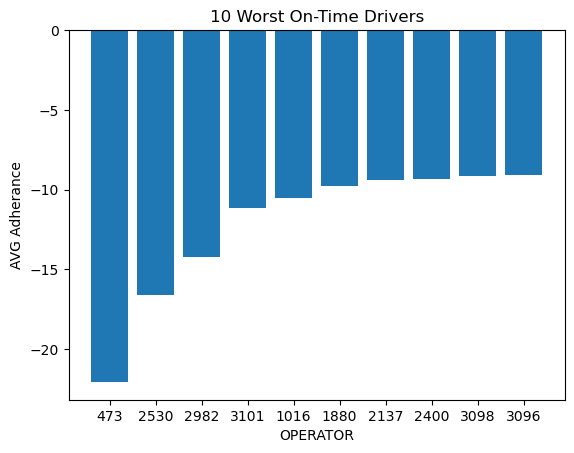

In [172]:
worst_drivers = theend.sort_values(by='AVG Adherance').head(10)
plt.bar(worst_drivers.index.astype(str), worst_drivers['AVG Adherance'])
plt.xlabel('OPERATOR')
plt.ylabel('AVG Adherance')
plt.title('10 Worst On-Time Drivers')
plt.show()

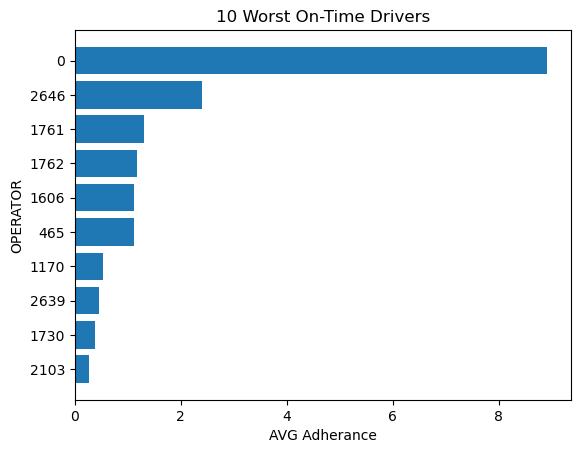

In [364]:
worst_drivers = theend.sort_values(by='AVG Adherance').tail(10)
plt.barh(worst_drivers.index.astype(str), worst_drivers['AVG Adherance'])
plt.xlabel('AVG Adherance')
plt.ylabel('OPERATOR')
plt.title('10 Worst On-Time Drivers')
plt.show()


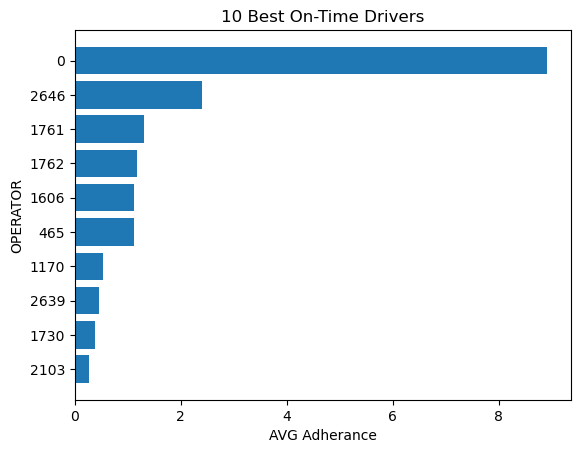

In [366]:
best_drivers = theend.sort_values(by='AVG Adherance').head(10)
plt.barh(worst_drivers.index.astype(str), worst_drivers['AVG Adherance'])
plt.xlabel('AVG Adherance')
plt.ylabel('OPERATOR')
plt.title('10 Best On-Time Drivers')
plt.show()

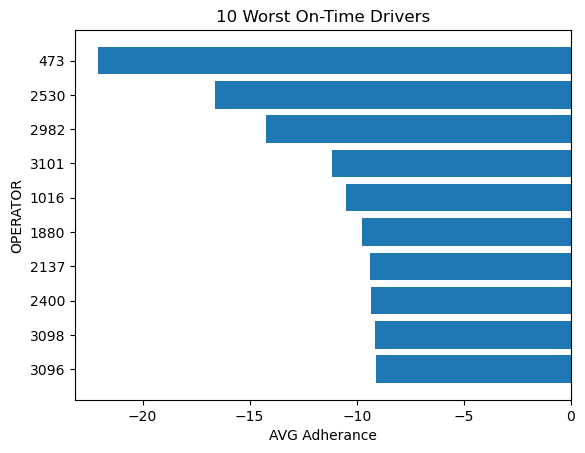

In [175]:
worst_drivers = theend.sort_values(by='AVG Adherance').head(10)
plt.barh(worst_drivers.index.astype(str), worst_drivers['AVG Adherance'])
plt.xlabel('AVG Adherance')
plt.ylabel('OPERATOR')
plt.title('10 Worst On-Time Drivers')
plt.gca().invert_yaxis()
plt.show()

In [178]:
experenced_drivers.sort_values(by='AVG Adherance').head(10)

,AVG Adherance,Trip count
OPERATOR,,
2109,-7.518872,2093
1204,-5.198442,2118
3031,-5.024775,2043
1590,-4.939848,2103
1650,-4.412999,2295
2706,-4.399192,2310
520,-4.380342,2134
326,-4.351053,2120
1623,-4.341682,2178


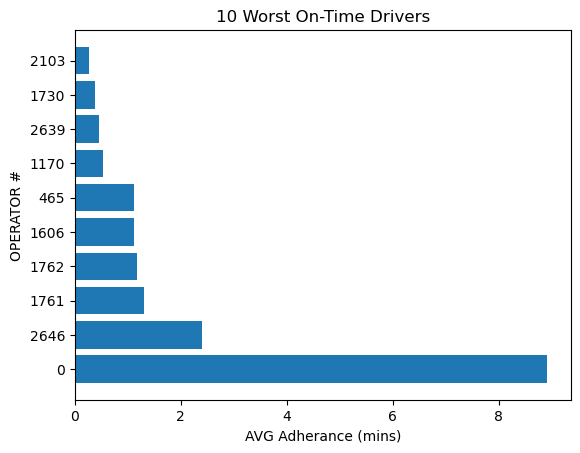

In [362]:
worst_drivers = theend.sort_values(by='AVG Adherance').tail(10)
plt.barh(worst_drivers.index.astype(str), worst_drivers['AVG Adherance'])
plt.xlabel('AVG Adherance (mins)')
plt.ylabel('OPERATOR #')
plt.title('10 Worst On-Time Drivers')
plt.gca().invert_yaxis()
plt.show()

In [360]:
worst_drivers = theend.sort_values(by='AVG Adherance').tail(10)
plt.barh(worst_drivers.index.astype(str), worst_drivers['AVG Adherance'])
plt.title (Worst Drivers)
plt.xlabel('AVG Adherance')
plt.ylabel('OPERATOR')
plt.show()

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3714070103.py, line 3)

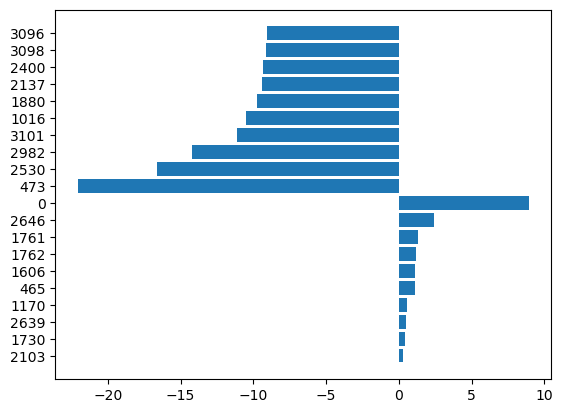

In [184]:
plt.barh(combined.index.astype(str),combined['AVG Adherance'])
plt.show()

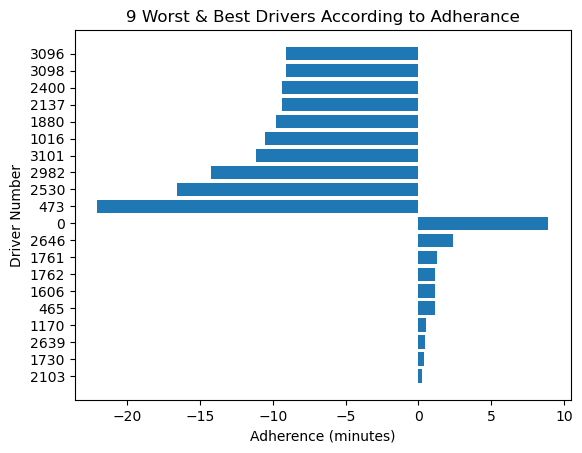

In [356]:
plt.barh(combined.index.astype(str),combined['AVG Adherance'])
plt.title('9 Worst & Best Drivers According to Adherance')
plt.xlabel('Adherence (minutes)')
plt.ylabel('Driver Number')
plt.show()

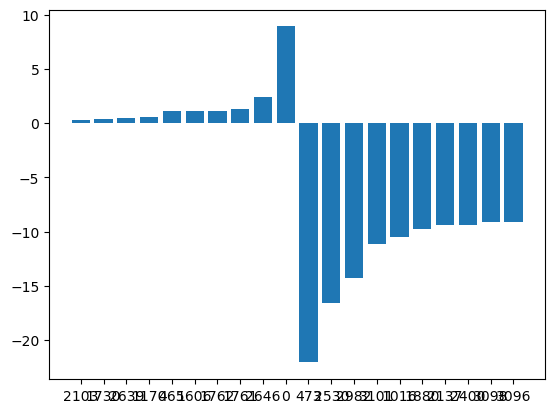

In [186]:
plt.bar(combined.index.astype(str),combined['AVG Adherance'])
plt.title('Distribution of Adherence (Early or Late)')
plt.xlabel('Adherence (minutes)')
plt.ylabel('Number of Trips')
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_21360\3377286572.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


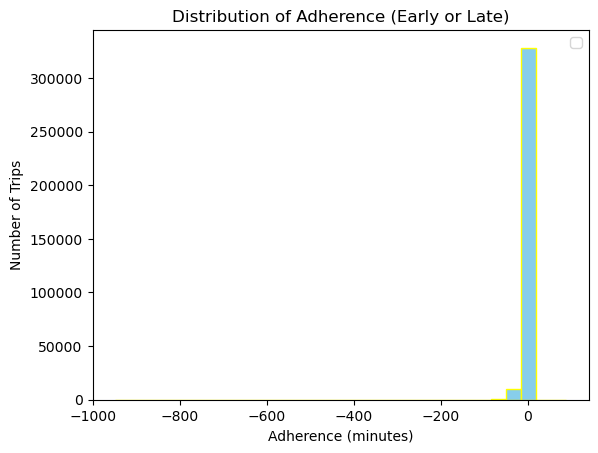

In [370]:
plt.hist(df_clean['ADHERENCE'], bins=30, color='skyblue', edgecolor='yellow')
plt.title('Distribution of Adherence (Early or Late)')
plt.xlabel('Adherence (minutes)')
plt.ylabel('Number of Trips')
plt.legend()
plt.show()

NameError: name 'overall_avg' is not defined

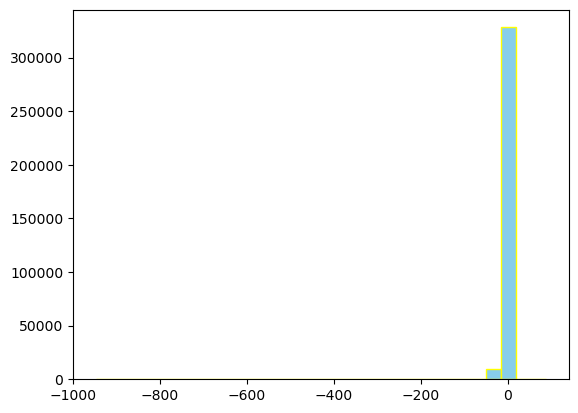

In [204]:
plt.hist(df_clean['ADHERENCE'], bins=30, color='skyblue', edgecolor='yellow')
plt.axvline(overall_avg, color='red', linestyle='dashed', label='Mean')
plt.axvline(overall_median, color='green', linestyle='dashed', label='Median')
plt.title('Distribution of Adherence (Early or Late)')
plt.xlabel('Adherence (minutes)')
plt.ylabel('Number of Trips')
plt.legend()
plt.show()


In [206]:
print(df_clean.dtypes)

CALENDAR_ID                           int64
SERVICE_ABBR                          int64
ADHERENCE_ID                          int64
DATE                                 object
ROUTE_ABBR                            int64
BLOCK_ABBR                            int64
OPERATOR                              int64
TRIP_ID                               int64
OVERLOAD_ID                           int64
ROUTE_DIRECTION_NAME                 object
TIME_POINT_ABBR                      object
ROUTE_STOP_SEQUENCE                 float64
TRIP_EDGE                             int64
LATITUDE                            float64
LONGITUDE                           float64
SCHEDULED_TIME               datetime64[ns]
ACTUAL_ARRIVAL_TIME                  object
ACTUAL_DEPARTURE_TIME                object
ADHERENCE                           float64
SCHEDULED_HDWY                      float64
ACTUAL_HDWY                         float64
HDWY_DEV                            float64
ADJUSTED_EARLY_COUNT            

In [212]:
print(df_clean['ADHERENCE'])


0         -2.133333
1         -2.450000
2         -0.933333
3          6.283333
4         -1.583333
            ...    
338856    -8.433333
338857   -11.300000
338858    -4.316666
338859   -22.083333
338860   -23.666666
Name: ADHERENCE, Length: 338861, dtype: float64


In [264]:
print(df_clean['ADHERENCE'].describe())


count    338861.000000
mean         -3.188796
std           6.898842
min        -948.533333
25%          -4.566666
50%          -2.000000
75%          -0.333333
max          88.383333
Name: ADHERENCE, dtype: float64


In [302]:
summary = df_clean.describe().T[['mean', 'std', 'min', 'max']]
summary[['mean', 'std,'min','25%','50%','75%','max']]
plt.figure(figsize=(12,6))
stats_to_plot.plot(kind='bar', color= 'blue', edgecolor='black')
plt.title('Stats for Adherence')
plt.ylabel('Minutes')
plt.tight_layout()
plt.show()

SyntaxError: unterminated string literal (detected at line 2) (3598441465.py, line 2)

<Figure size 1200x600 with 0 Axes>

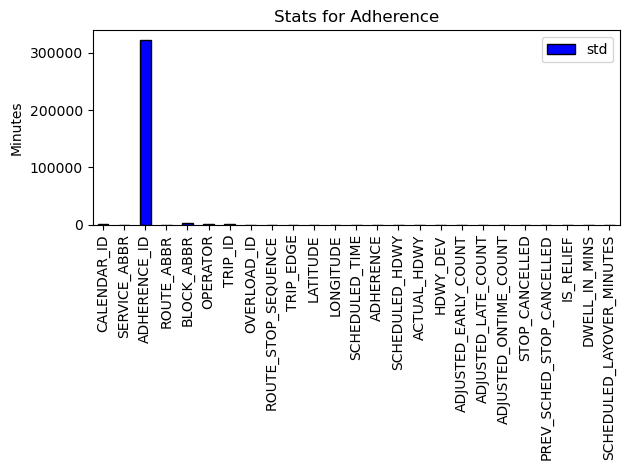

In [304]:
summary = df_clean.describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
plt.figure(figsize=(12,6))
summary[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].plot(kind='bar', color='blue', edgecolor='black')
plt.title('Stats for Adherence')
plt.ylabel('Minutes')
plt.tight_layout()
plt.show()

In [ ]:
ound= df_clean['ADHERENCE'].round()
count=round.value_counts().sort_index

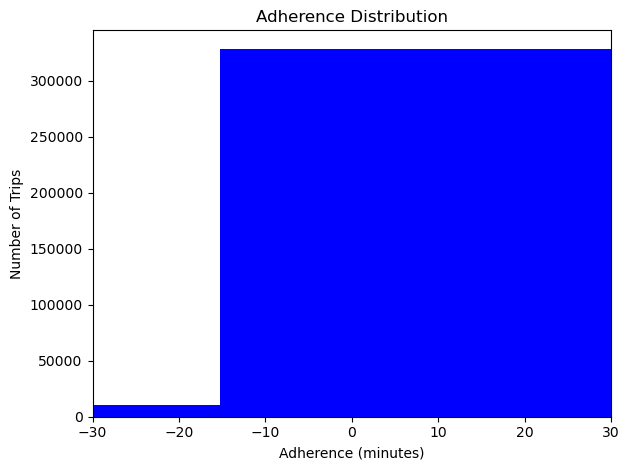

In [418]:
plt.hist(df_clean['ADHERENCE'],color='blue')
plt.title('Adherence Distribution')
plt.xlabel('Adherence (minutes)')
plt.ylabel('Number of Trips')
plt.xlim(-30,30)
plt.tight_layout()
plt.show()

AttributeError: Line2D.set() got an unexpected keyword argument 'kde'

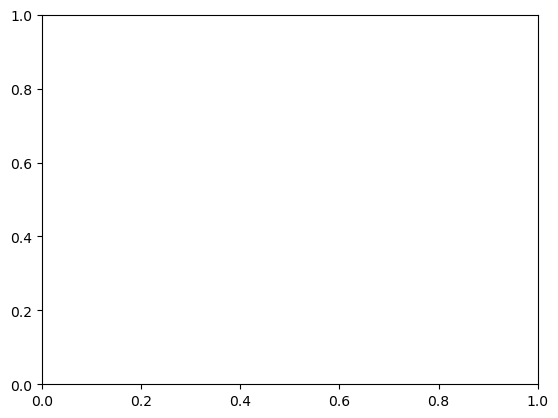

In [426]:
adh_count= df_clean['ADHERENCE'].dropna().round().value_counts().sort_index()
plt.plot(adh_count.index,adh_count.values,kde=True,color='blue')
plt.xlim(-30,30)
plt.title('Adherence Distribution')
plt.xlabel('Adherence (minutes)')
plt.ylabel('Number of Trips')
plt.tight_layout()
plt.show()

In [ ]:
adh_count= df_clean['ADHERENCE'].round().value_counts().sort_index()
plt.plot(adh_count.index,adh_count.values,color='blue')
plt.title('Adherence Distribution')
plt.xlabel('Adherence (minutes)')
plt.ylabel('Number of Trips')
plt.tight_layout()
plt.show()

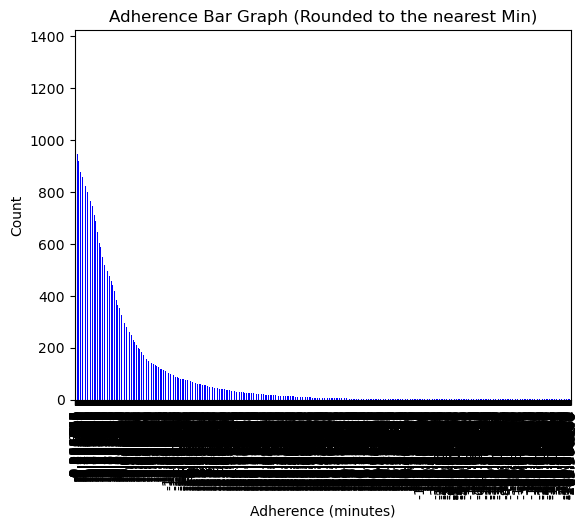

In [340]:
count = df_clean['ADHERENCE'].value_counts()
count.plot(kind='bar', color='blue')
plt.title('Adherence Bar Graph (Rounded to the nearest Min)')
plt.xlabel('Adherence (minutes)')
plt.ylabel('Count')
plt.show()

In [374]:
triprt_medians=df_clean.groupby(['ROUTE_ABBR','TRIP_ID'])['ADHERENCE'].MEDIAN().RESET_INDEX()AttributeError                            Traceback (most recent call last)
Cell In[374], line 1
----> 1 triprt_medians=df_clean.groupby(['ROUTE_ABBR','TRIP_ID'])['ADHERENCE'].MEDIAN().RESET_INDEX()

File ~\anaconda3\envs\geospatial\lib\site-packages\pandas\core\groupby\groupby.py:1363, in GroupBy.__getattr__(self, attr)
   1360 if attr in self.obj:
   1361     return self[attr]
-> 1363 raise AttributeError(
   1364     f"'{type(self).__name__}' object has no attribute '{attr}'"
   1365 )

AttributeError: 'SeriesGroupBy' object has no attribute 'MEDIAN'

AttributeError: 'SeriesGroupBy' object has no attribute 'MEDIAN'

In [406]:
triprt_medians = df_clean.groupby(['ROUTE_ABBR', 'TRIP_ID'])['ADHERENCE'].mean().reset_index()

In [408]:
print(triprt_medians)

      ROUTE_ABBR  TRIP_ID  ADHERENCE
0              3   346048  -1.548485
1              3   346049  -5.972222
2              3   346050  -0.602222
3              3   346051  -4.851111
4              3   346052  -0.156667
...          ...      ...        ...
3982          56   353120  -5.688489
3983          56   353121  -4.108542
3984          56   353122  -3.170397
3985          56   353123  -5.831250
3986          56   354106 -15.559701

[3987 rows x 3 columns]


In [410]:
rout_sum=triprt_medians.groupby('ROUTE_ABBR')['ADHERENCE'].mean().sort_values()

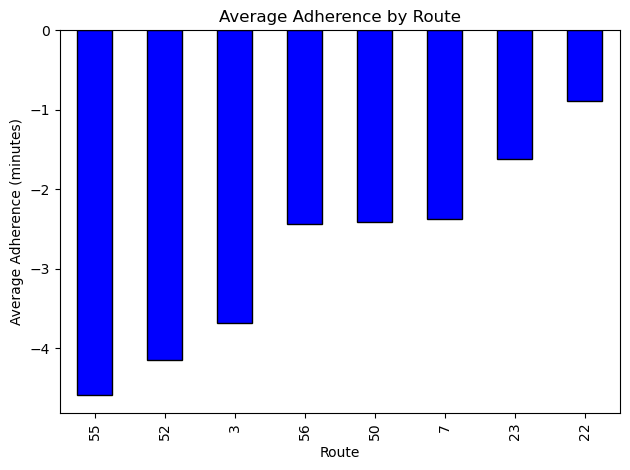

In [412]:
rout_sum.plot(kind='bar', color='blue', edgecolor='black')
plt.title('Average Adherence by Route')
plt.xlabel('Route')
plt.ylabel('Average Adherence (minutes)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

AttributeError: module 'matplotlib.pyplot' has no attribute 'xlable'

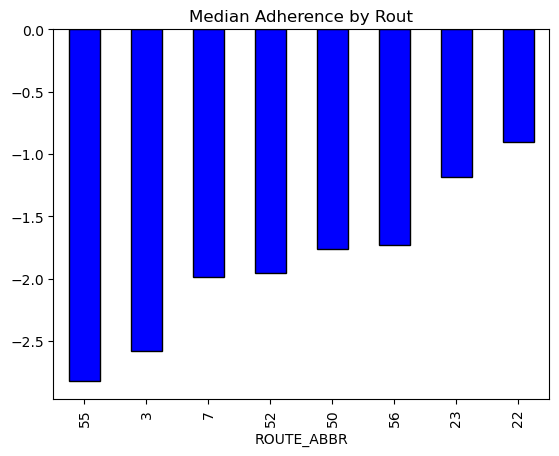

In [390]:
rout_sum.plot(kind='bar',color='blue', edgecolor='black')
plt.title('Median Adherence by Rout')
plt.xlable('Route')
plt.ylable('Median Adherence (minutes)')
plt.xticks(rotation=90)
plt.show

In [286]:
count.plot(kind='bar', color= 'blue', edgecolor='black')
plt.title('Adherence Bar Graph( Rounded to the nearest Min)')
plt.xlabel('Adherence (minutes)')
plt.ylabel('Number of Trips')
plt.show()

AttributeError: 'function' object has no attribute 'plot'

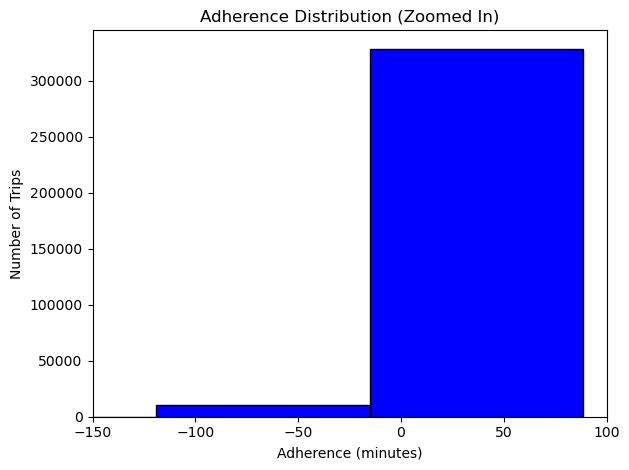

In [322]:
plt.hist(df_cleanROUTE_ABBR,color='blue',edgecolor='black')
plt.xlim(-150,100)
plt.title('Adherence Distribution (Zoomed In)')
plt.xlabel('Adherence (minutes)')
plt.ylabel('Number of Trips')
plt.tight_layout()
plt.show()

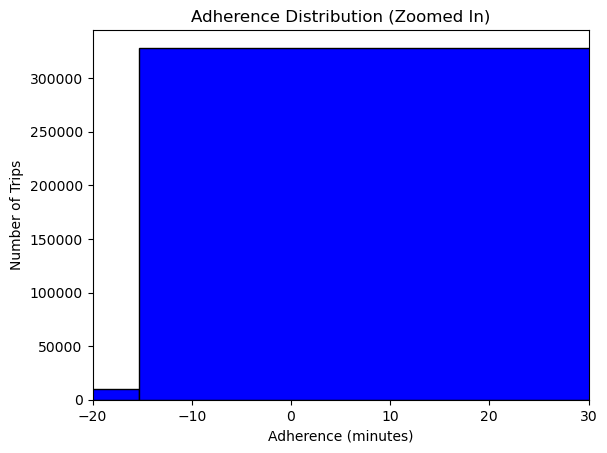

In [278]:
plt.hist(df_clean['ADHERENCE'],color='blue',edgecolor='black')
plt.xlim(-20,30)
plt.title('Adherence Distribution (Zoomed In)')
plt.xlabel('Adherence (minutes)')
plt.ylabel('Number of Trips')
plt.show()

In [342]:
plt.(df_clean['ADHERENCE'],color='blue',edgecolor='black')
plt.xlim(-20,30)
plt.title('Adherence Distribution (Zoomed In)')
plt.xlabel('Adherence (minutes)')
plt.ylabel('Number of Trips')
plt.show()

SyntaxError: invalid syntax (1808615923.py, line 1)

In [258]:
max_ovall=df_clean['ADHERENCE'].max()
print(max_ovall)

88.383333


In [260]:
min_ovall=df_clean['ADHERENCE'].min()
print(min_ovall)

-948.533333


In [198]:
med_ovall=df_clean['ADHERENCE'].median()
print(med_ovall)

-2.0


In [196]:
avg_ovall=df_clean['ADHERENCE'].mean()
print(avg_ovall)


-3.1887964314276354


In [216]:
trip_avg=df_clean.groupby('TRIP_ID')['ADHERENCE'].mean().reset_index()

In [220]:
def label_adherence(x):
    if x <-5: return 'very early'
        else if -5<=x<=2:
            return 'early'
        else if -2<=x=2: 
            return 'on time'
        else if 2<x<=5: 
            return 'late'
        else: 
            return 'very late'
df_clean['ADHERENCE'].apply(label_adherence)

IndentationError: unexpected indent (3703356596.py, line 3)

In [252]:
def label_adherence(x):
    if x < -5:
        return 'Very Early'
    elif -5 <= x < -2:
        return 'Early'
    elif -2 <= x <= 2:
        return 'On Time'
    elif 2 < x <= 5:
        return 'Late'
    else:
        return 'Very Late'

df_clean['ADHERENCE_LABEL'] = df_clean['ADHERENCE'].apply(label_adherence)

In [254]:
print(df_clean['ADHERENCE_LABEL'].value_counts(normalize=True)*100)

ADHERENCE_LABEL
On Time       43.842756
Early         27.641717
Very Early    22.311803
Late           4.590083
Very Late      1.613641
Name: proportion, dtype: float64


In [334]:
label_adherence=df_clean['ADHERENCE_LABEL'].value_counts().reindex(['On Time','Early','Very Early,Late','Very Late'])
bars

NameError: name 'PRINT' is not defined

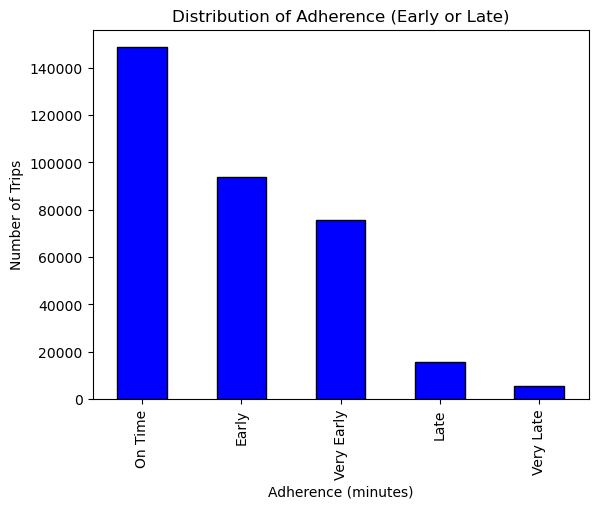

In [328]:
label_adherence=df_clean['ADHERENCE_LABEL'].value_counts()
label_adherence.plot(kind='bar', color='blue', edgecolor='black')
plt.title('Distribution of Adherence (Early or Late)')
plt.xlabel('Adherence (minutes)')
plt.ylabel('Number of Trips')
plt.show()

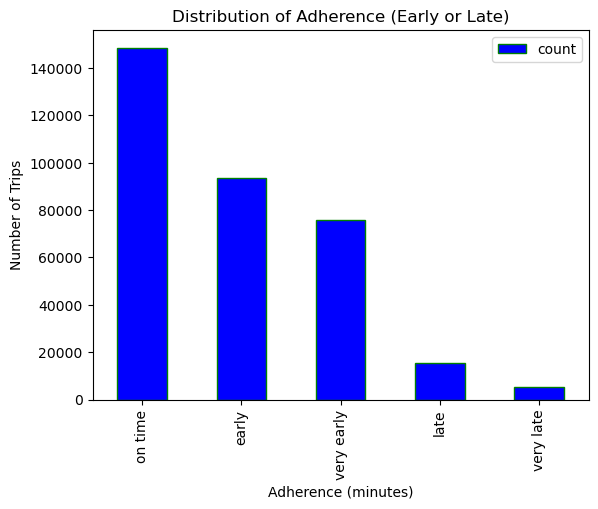

In [240]:
label_adherence=df_clean['ADHERENCE_LABEL'].value_counts()
label_adherence.plot(kind='bar', color='blue', edgecolor='green')
plt.title('Distribution of Adherence (Early or Late)')
plt.xlabel('Adherence (minutes)')
plt.ylabel('Number of Trips')
plt.legend()
plt.show()

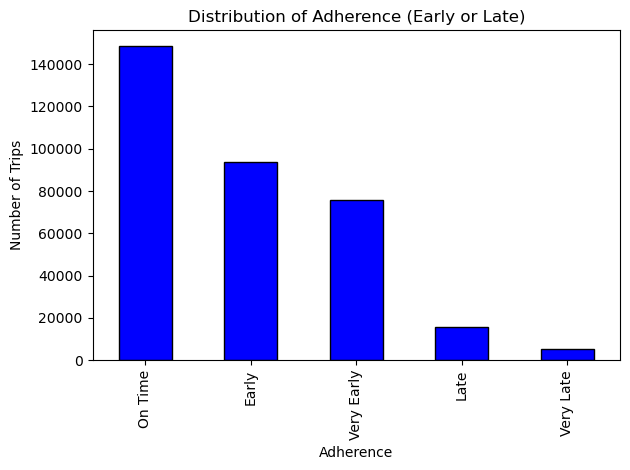

In [338]:
label_adherence=df_clean['ADHERENCE_LABEL'].value_counts()
label_adherence.plot(kind='bar', color='blue', edgecolor='black')
plt.title('Distribution of Adherence (Early or Late)')
plt.xlabel('Adherence')
plt.ylabel('Number of Trips')
plt.tight_layout()
plt.show()

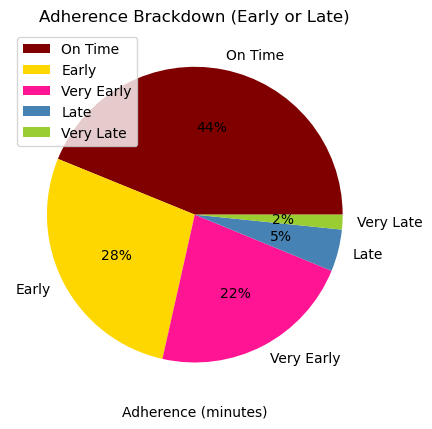

In [448]:
label_adherence=df_clean['ADHERENCE_LABEL'].value_counts()
label_adherence.plot.pie(autopct='%1.0f%%', colors=['maroon', 'gold', 'deeppink', 'steelblue', 'yellowgreen'])
plt.title('Adherence Brackdown (Early or Late)')
plt.xlabel('Adherence (minutes)')
plt.ylabel('')
plt.legend()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_21360\392542725.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


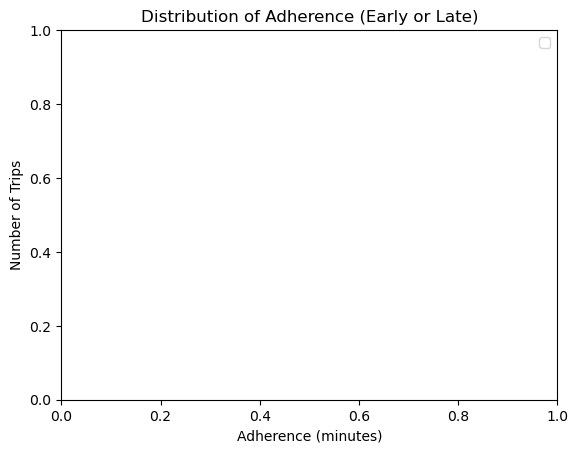

In [236]:
df_clean['ADHERENCE_LABEL'].value_counts(normalize=True)*100
plt.title('Distribution of Adherence (Early or Late)')
plt.xlabel('Adherence (minutes)')
plt.ylabel('Number of Trips')
plt.legend()
plt.show()
                         

In [ ]:
tp_cnt=df_clean[OPERATOR'].v

In [ ]:
mixer=pd.dataframe(df_clean